# 05 Xenium Annotation & Neighborhoods

Starter notebook for Xenium annotation transfer and neighborhood analysis.

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

## Load Xenium + reference and choose transfer label

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
XENIUM_H5 = PROJECT_ROOT / "data" / "xenium" / "xenium_qc_exploration.h5ad"
REFERENCE_H5 = PROJECT_ROOT / "data" / "reference" / "reference_qc_annotated_for_transfer.h5ad"
OUT_DIR = PROJECT_ROOT / "data" / "xenium"
OUT_DIR.mkdir(parents=True, exist_ok=True)

adata_xenium = sc.read_h5ad(XENIUM_H5)
adata_ref = sc.read_h5ad(REFERENCE_H5)

label_candidates = [
    "cell_type",
    "celltype",
    "cell_type_major",
    "majorlineage",
    "major_lineage",
    "annotation",
    "annot",
    "label",
]
label_key = next((c for c in label_candidates if c in adata_ref.obs.columns), None)
if label_key is None:
    raise KeyError(
        f"None of the expected label columns found in reference.obs. "
        f"Tried: {label_candidates}"
    )

adata_ref.obs[label_key] = adata_ref.obs[label_key].astype(str).fillna("Unknown")

print("Loaded Xenium:", adata_xenium.shape)
print("Loaded reference:", adata_ref.shape)
print("Transfer label column:", label_key)
print("Reference label counts (top 10):")
print(adata_ref.obs[label_key].value_counts().head(10))

Loaded Xenium: (141868, 313)
Loaded reference: (16692, 3000)
Transfer label column: cell_type
Reference label counts (top 10):
cell_type
Epithelial cells          10652
T cells                    2730
Breast glandular cells     1082
Breast cancer               819
B cells                     360
Endothelial cells           356
Macrophages                 333
NK cells                    205
Fibroblasts                 131
Adipocytes                   24
Name: count, dtype: int64


## Transfer reference labels to Xenium with Scanpy ingest

Shared genes: 181


/tmp/ipykernel_798184/342516660.py:13: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata_ref_t, target_sum=1e4)
/tmp/ipykernel_798184/342516660.py:15: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata_ref_t, flavor="seurat_v3", n_top_genes=min(3000, adata_ref_t.n_vars))
/home/katwre/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Predicted labels added to Xenium: adata_xenium.obs['pred_cell_type']
pred_cell_type
Epithelial cells          43997
T cells                   38725
Breast glandular cells    18746
Fibroblasts               15401
NK cells                   8374
Macrophages                6881
Endothelial cells          5916
Breast cancer              1904
B cells                    1903
Adipocytes                   21
Name: count, dtype: int64


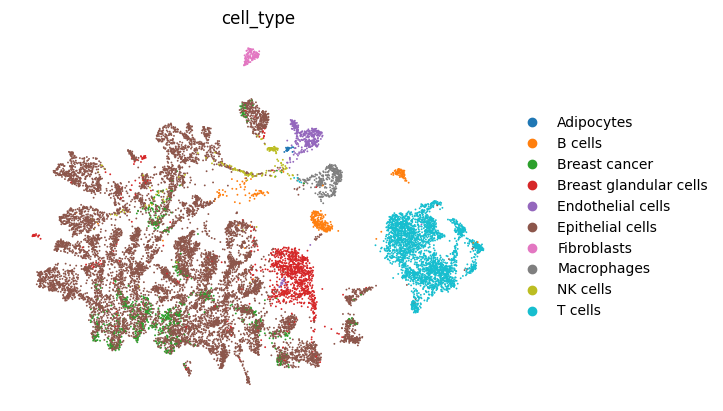

In [4]:
shared_genes = adata_ref.var_names.intersection(adata_xenium.var_names)
print(f"Shared genes: {len(shared_genes):,}")
if len(shared_genes) < 50:
    raise ValueError("Too few shared genes for robust transfer (<50).")

adata_ref_t = adata_ref[:, shared_genes].copy()
adata_xenium_t = adata_xenium[:, shared_genes].copy()

for adata in (adata_ref_t, adata_xenium_t):
    if "counts" in adata.layers:
        adata.X = adata.layers["counts"].copy()

sc.pp.normalize_total(adata_ref_t, target_sum=1e4)
sc.pp.log1p(adata_ref_t)
sc.pp.highly_variable_genes(adata_ref_t, flavor="seurat_v3", n_top_genes=min(3000, adata_ref_t.n_vars))

hvg_mask = adata_ref_t.var["highly_variable"].values
adata_ref_t = adata_ref_t[:, hvg_mask].copy()
adata_xenium_t = adata_xenium_t[:, adata_ref_t.var_names].copy()

sc.pp.scale(adata_ref_t, max_value=10)
sc.tl.pca(adata_ref_t, svd_solver="arpack")
sc.pp.neighbors(adata_ref_t, n_neighbors=15, n_pcs=min(30, adata_ref_t.obsm["X_pca"].shape[1]))
sc.tl.umap(adata_ref_t)

sc.tl.ingest(adata_xenium_t, adata_ref_t, obs=label_key)
adata_xenium.obs["pred_cell_type"] = adata_xenium_t.obs[label_key].astype(str).values

print("Predicted labels added to Xenium: adata_xenium.obs['pred_cell_type']")
print(adata_xenium.obs["pred_cell_type"].value_counts().head(15))

sc.pl.umap(adata_ref_t, color=[label_key], frameon=False)

## Spatial neighborhoods and enrichment

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:13<00:00, 72.40/s]


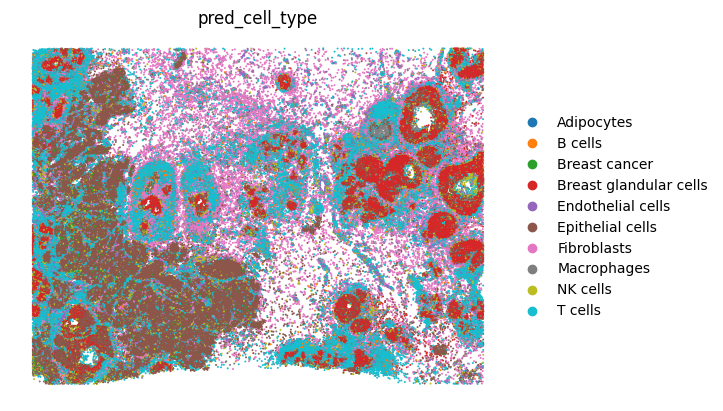

pred_cell_type,Adipocytes,B cells,Breast cancer,Breast glandular cells,Endothelial cells,Epithelial cells,Fibroblasts,Macrophages,NK cells,T cells
leiden,,,,,,,,,,
0,0,1,1498,211,0,28319,2,6,1709,177
1,0,0,182,12701,0,4996,0,1,960,69
2,0,0,18,156,43,2001,11500,49,1073,2883
3,0,1,6,40,18,401,397,14,13,13507
4,0,32,14,154,7,606,780,6345,428,4320
5,21,4,21,14,5804,865,541,42,1485,2494
6,0,0,73,4659,0,2849,78,3,2082,912
7,0,0,5,30,24,327,203,34,28,7652
8,0,962,1,21,5,123,509,68,89,2592


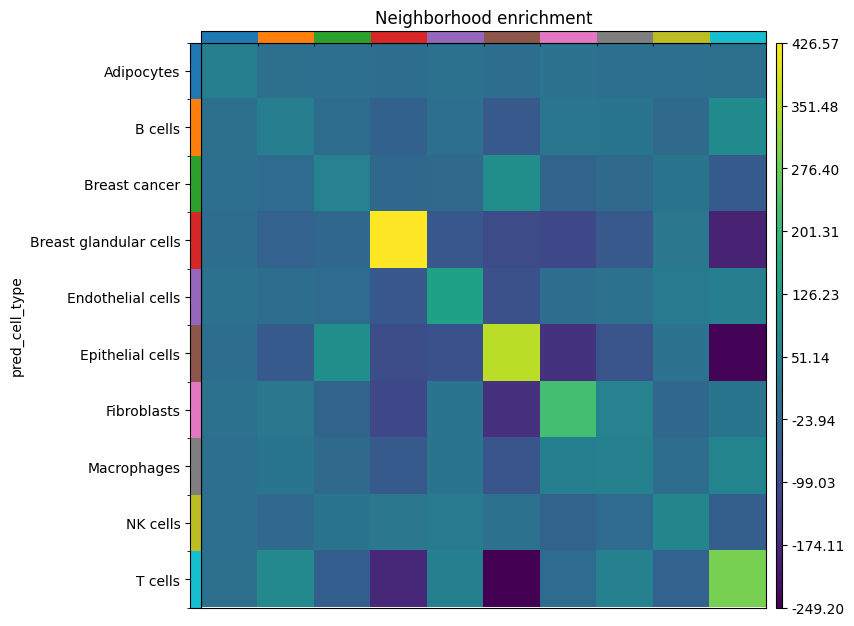

In [7]:
if "spatial" not in adata_xenium.obsm:
    raise KeyError("Xenium object has no obsm['spatial']; run Notebook 4 with spatial coordinates attached.")

if "pred_cell_type" not in adata_xenium.obs:
    raise KeyError("pred_cell_type not found in adata_xenium.obs; run Cell 6 first.")

adata_xenium.obs["pred_cell_type"] = (
    adata_xenium.obs["pred_cell_type"]
    .astype(str)
    .fillna("Unknown")
    .astype("category")
)

sq.gr.spatial_neighbors(adata_xenium, coord_type="generic")
sq.gr.nhood_enrichment(adata_xenium, cluster_key="pred_cell_type")

if "spatial" in adata_xenium.uns:
    sq.pl.spatial_scatter(
        adata_xenium,
        color="pred_cell_type",
        coord_type="generic",
        size=8,
        legend_loc="right margin",
    )
else:
    sc.pl.embedding(
        adata_xenium,
        basis="spatial",
        color="pred_cell_type",
        size=8,
        frameon=False,
    )

sq.pl.nhood_enrichment(adata_xenium, cluster_key="pred_cell_type")

if "leiden" in adata_xenium.obs:
    ctab = pd.crosstab(adata_xenium.obs["leiden"], adata_xenium.obs["pred_cell_type"])
    display(ctab)
else:
    print("No leiden column found in Xenium obs; skipping contingency table.")

## Save annotated Xenium object and neighborhood matrix

In [8]:
xenium_annot_fp = OUT_DIR / "xenium_annotated_neighborhoods.h5ad"
adata_xenium.write_h5ad(xenium_annot_fp)
print(f"Saved: {xenium_annot_fp}")

enrich_key = "pred_cell_type_nhood_enrichment"
if enrich_key in adata_xenium.uns:
    z = pd.DataFrame(
        adata_xenium.uns[enrich_key]["zscore"],
        index=adata_xenium.obs["pred_cell_type"].astype("category").cat.categories,
        columns=adata_xenium.obs["pred_cell_type"].astype("category").cat.categories,
    )
    z_fp = OUT_DIR / "xenium_pred_cell_type_neighborhood_zscore.csv"
    z.to_csv(z_fp)
    print(f"Saved: {z_fp}")
else:
    print(f"No {enrich_key} found in adata_xenium.uns; skipping CSV export.")

Saved: ../data/xenium/xenium_annotated_neighborhoods.h5ad
Saved: ../data/xenium/xenium_pred_cell_type_neighborhood_zscore.csv
